[nltk_data] Downloading package punkt to C:\Users\VIVOBBOK
[nltk_data]     16\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\VIVOBBOK
[nltk_data]     16\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\VIVOBBOK
[nltk_data]     16\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\VIVOBBOK 16\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Dataset Shape: (14640, 15)

Columns: Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

Missing Values:
 tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

Sample tweets for sentiment: ne

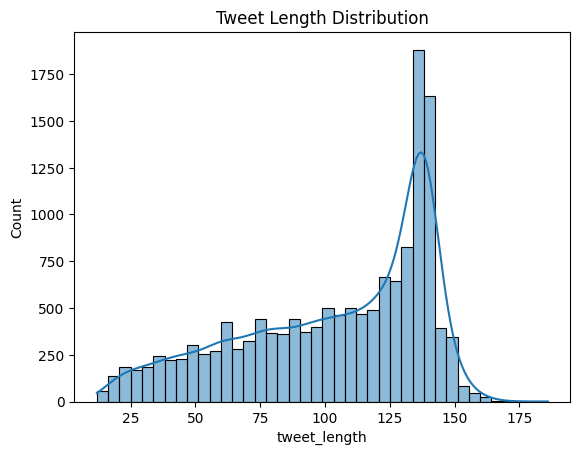


Average Hashtags: 0.23920765027322405
Average Mentions: 1.1275273224043716
Average URLs: 0.08271857923497268


In [1]:
#  Step 1: Import Libraries

import pandas as pd
import numpy as np
import re
import time
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from emoji import demojize

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk import word_tokenize, pos_tag, sent_tokenize


#  Step 2: Load Dataset

df = pd.read_csv("Tweets.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

# Use only needed columns
df = df[['airline_sentiment', 'text']]
df.dropna(inplace=True)


#  Step 3: Explore Dataset

# Sample tweets by sentiment
for s in df['airline_sentiment'].unique():
    print(f"\nSample tweets for sentiment: {s}")
    print(df[df['airline_sentiment'] == s]['text'].head(3).to_string(index=False))

# Tweet length
df['tweet_length'] = df['text'].apply(len)
sns.histplot(df['tweet_length'], bins=40, kde=True)
plt.title("Tweet Length Distribution")
plt.show()

# Hashtags, mentions, URLs
df['hashtags'] = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['mentions'] = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['urls'] = df['text'].apply(lambda x: len(re.findall(r'http\S+', str(x))))

print("\nAverage Hashtags:", df['hashtags'].mean())
print("Average Mentions:", df['mentions'].mean())
print("Average URLs:", df['urls'].mean())


In [2]:

#  Step 4: Clean Text Function

import contractions

def clean_text(text, keep_hashtags=False, emoji_option='remove'):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)               # Remove URLs
    text = re.sub(r'@\w+', '', text)                         # Remove mentions
    if not keep_hashtags:
        text = re.sub(r'#\w+', '', text)                     # Remove hashtags
    else:
        text = re.sub(r'#', '', text)
    text = re.sub(r'\d+', '', text)                          # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)                      # Remove punctuation
    text = contractions.fix(text)                            # Expand contractions
    if emoji_option == 'text':
        text = demojize(text)                                # Convert emoji to text
    elif emoji_option == 'remove':
        text = re.sub(r'[^\x00-\x7F]+', '', text)            # Remove emojis
    text = re.sub(r'(.)\1{2,}', r'\1', text)                 # Handle repeated chars
    text = re.sub(r'\s+', ' ', text).strip()                 # Extra spaces
    return text

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)
print(df[['text', 'clean_text']].head())


                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                          clean_text  
0                                          what said  
1  plus you have added commercials to the experie...  
2  i did not today must mean i need to take anoth...  
3  its really aggressive to blast obnoxious enter...  
4            and its a really big bad thing about it  


In [3]:

#  Step 5: Tokenization

sample = df['clean_text'].iloc[0]
print("Original:", sample)
print("\nWord Tokenize:", word_tokenize(sample))
print("\nSentence Tokenize:", sent_tokenize(sample))


#  Step 6: Stopword Removal

stop_words = set(stopwords.words('english'))
custom_stopwords = stop_words.union({'im', 'rt', 'via'})
negation_words = {"not", "no", "never"}

def remove_stopwords(tokens):
    return [t for t in tokens if (t not in custom_stopwords or t in negation_words)]

tokens = word_tokenize(sample)
filtered = remove_stopwords(tokens)
print("\nAfter Stopword Removal:", filtered)


#  Step 7: Stemming & Lemmatization

porter = PorterStemmer()
snowball = SnowballStemmer("english")
lemmatizer = WordNetLemmatizer()

words = ["running", "runs", "ran", "better", "good", "best"]
print("\nStemming & Lemmatization Comparison:")
for w in words:
    print(f"{w} → {porter.stem(w)}, {snowball.stem(w)}, {lemmatizer.lemmatize(w, 'v')}")


#  Step 8: POS Tagging

tokens = word_tokenize(sample)
pos_tags = pos_tag(tokens)
print("\nPOS Tags:", pos_tags)

nouns_adj = [word for word, pos in pos_tags if pos.startswith('N') or pos.startswith('J')]
print("\nNouns & Adjectives:", nouns_adj)


Original: what said

Word Tokenize: ['what', 'said']

Sentence Tokenize: ['what said']

After Stopword Removal: ['said']

Stemming & Lemmatization Comparison:
running → run, run, run
runs → run, run, run
ran → ran, ran, run
better → better, better, better
good → good, good, good
best → best, best, best

POS Tags: [('what', 'WP'), ('said', 'VBD')]

Nouns & Adjectives: []


In [6]:
# Step 9: spaCy Processing 

import spacy
from spacy import displacy
import matplotlib.pyplot as plt
import seaborn as sns

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download
    download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

text = df['clean_text'].dropna().iloc[0]
doc = nlp(text)

print('\nTokens:', [token.text for token in doc])
print('\nLemmas:', [token.lemma_ for token in doc])
print('\nPOS:', [(token.text, token.pos_) for token in doc])

if len(doc.ents) > 0:
    entity_labels = [ent.label_ for ent in doc.ents]
    plt.figure(figsize=(6, 3))
    sns.countplot(y=entity_labels)
    plt.title('Named Entity Frequency')
    plt.show()

try:
    html = displacy.render(doc, style='dep', page=True, jupyter=False)
    with open('dependency_tree.html', 'w', encoding='utf-8') as f_html:
        f_html.write(html)
    print("\nDependency tree saved as 'dependency_tree.html'")
except Exception as e:
    print(f'Could not render dependency tree: {e}')



Tokens: ['what', 'said']

Lemmas: ['what', 'say']

POS (Part of Speech): [('what', 'PRON'), ('said', 'VERB')]

Entities: []
No named entities found in this text.
 Could not render dependency tree: cannot import name 'display' from 'IPython.core.display' (C:\Users\VIVOBBOK 16\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\display.py)


In [7]:

#  Step 10: Performance Comparison

def process_with_nltk(texts):
    start = time.time()
    for t in texts:
        tokens = word_tokenize(clean_text(t))
        tokens = remove_stopwords(tokens)
        _ = [lemmatizer.lemmatize(tok) for tok in tokens]
    return time.time() - start

def process_with_spacy(texts):
    start = time.time()
    for doc in nlp.pipe(texts, disable=["parser", "ner"]):
        _ = [token.lemma_ for token in doc if not token.is_stop]
    return time.time() - start

subset_1k = df['text'][:1000].tolist()
subset_5k = df['text'][:5000].tolist()

nltk_time = process_with_nltk(subset_1k)
spacy_time = process_with_spacy(subset_1k)

print(f"\nProcessing Time on 1k Tweets → NLTK: {nltk_time:.2f}s | spaCy: {spacy_time:.2f}s")



Processing Time on 1k Tweets → NLTK: 0.23s | spaCy: 3.64s


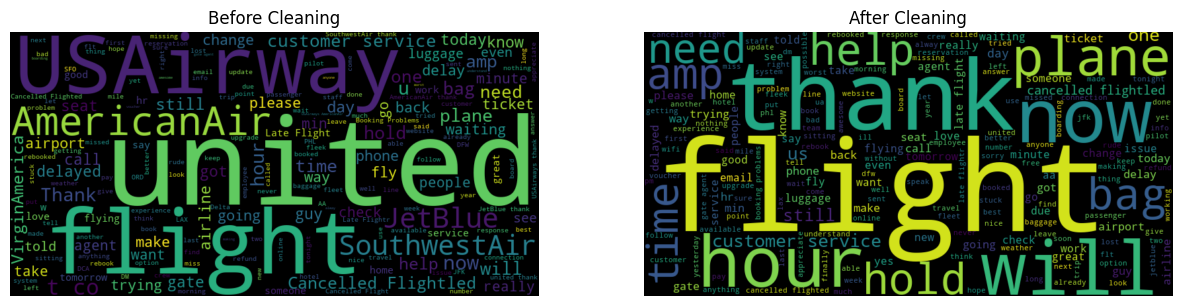

In [8]:

#  Step 11: Visualization & Vocabulary

# Word cloud before vs after
wc_before = WordCloud(width=800, height=400).generate(" ".join(df['text']))
wc_after = WordCloud(width=800, height=400).generate(" ".join(df['clean_text']))

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis('off')
plt.title("Before Cleaning")

plt.subplot(1,2,2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis('off')
plt.title("After Cleaning")
plt.show()


In [10]:

#  Step 12: Observations Summary

print("""
1️ Vocabulary size reduces significantly after preprocessing.
2️ spaCy is faster for larger datasets (thanks to pipeline optimization).
3️ Lemmatization quality is higher in spaCy.
4️ NLTK provides more control and flexibility in individual preprocessing steps.
5️ Standard stopword lists miss social media slang and abbreviations.
6️ Social media text is noisy — emojis, hashtags, and mentions require extra care.
""")



1️ Vocabulary size reduces significantly after preprocessing.
2️ spaCy is faster for larger datasets (thanks to pipeline optimization).
3️ Lemmatization quality is higher in spaCy.
4️ NLTK provides more control and flexibility in individual preprocessing steps.
5️ Standard stopword lists miss social media slang and abbreviations.
6️ Social media text is noisy — emojis, hashtags, and mentions require extra care.



In [ ]:
# Step 13: N-Grams Analysis
from collections import Counter
from nltk.util import ngrams

def get_top_ngrams(corpus, n, k=10):
    all_text = ' '.join(corpus)
    tokens = all_text.split()
    n_grams = ngrams(tokens, n)
    return Counter(n_grams).most_common(k)

try:
    top_bi_grams = get_top_ngrams(df['clean_text'].dropna(), 2)
    bi_words, bi_counts = zip(*[(f'{w1} {w2}', c) for (w1, w2), c in top_bi_grams])
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(bi_counts), y=list(bi_words), palette='magma')
    plt.title('Top 10 Most Common Bi-grams')
    plt.show()
except Exception as e:
    print(f'N-gram error: {e}')


In [ ]:
# Step 14: ML Classification Evaluation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

try:
    X = df['clean_text'].fillna('')
    y = df['airline_sentiment']
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    X_tfidf = tfidf.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
    print('\nReport:\n', classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred, labels=y.unique())
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=y.unique(), yticklabels=y.unique())
    plt.title('Confusion Matrix')
    plt.show()
except Exception as e:
    print(f'ML error: {e}')
